## Self-Supervised Image Segmentation from a Single Image

This project focuses on segmenting a single image into semantically meaningful regions in the absence of any ground truth labels. A self-supervised contrastive learning framework is employed to train a convolutional neural network (CNN) encoder capable of generating robust feature embeddings for image patches. These embeddings are subsequently clustered to generate segmentation maps.

The proposed method is particularly beneficial in scenarios where labeled data is limited or entirely unavailable, such as medical imaging, rare satellite captures, or niche industrial applications.

The work done below comprises of the following steps:
- Loading and preprocessing of a single image.
- Extraction and augmentation of image patches to enhance representation learning.
- Training of a patch encoder using a contrastive loss function to learn discriminative embeddings.
- Clustering of patch embeddings to form distinct groups.
- Reconstruction of the segmentation map by assigning cluster labels back to the original image layout.


## Setup and Imports

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as T
import torchvision.transforms as TF
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from scipy.ndimage import center_of_mass

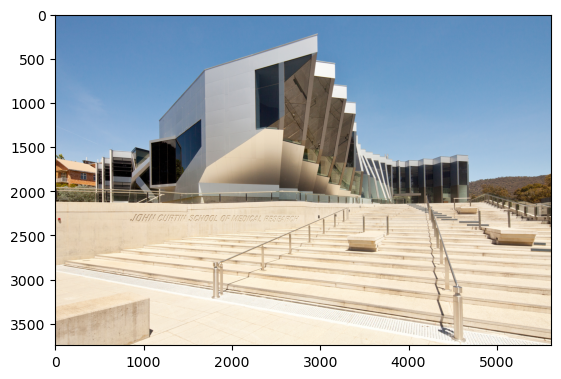

In [30]:
img = Image.open('jcsmr.jpg').convert("RGB")
#img = img.resize((256, 256))  # for faster processing
plt.imshow(img)

## Create Patches and Apply Augmentations

The input image is divided into multiple small patches, which serve as the base units for contrastive learning. To create positive pairs, each patch undergoes a series of augmentations, including color jitter and Gaussian blur. These augmentations help the model learn invariant features by encouraging it to produce similar embeddings for differently augmented versions of the same patch.


In [31]:
def extract_patches(image, patch_size=32, num_patches=500):
    patches = []
    w, h = image.size
    for _ in range(num_patches):
        x = np.random.randint(0, w - patch_size)
        y = np.random.randint(0, h - patch_size)
        patch = image.crop((x, y, x + patch_size, y + patch_size))
        patches.append(patch)
    return patches

patches = extract_patches(img)

In [32]:
augment = TF.Compose([
    TF.RandomResizedCrop(32, scale=(0.8, 1.0)),
    TF.RandomHorizontalFlip(),
    TF.ColorJitter(0.4, 0.4, 0.4, 0.1),
    TF.ToTensor()
])
def make_augmented_pairs(patches):
    pairs = []
    for patch in patches:
        view1 = augment(patch)
        view2 = augment(patch)
        pairs.append((view1, view2))
    return pairs

## Define Patch Encoder (CNN)

A small CNN maps each patch into an embedding vector. The goal is to learn meaningful representations using a contrastive loss.


In [33]:
# Simple CNN encoder
class PatchEncoder(nn.Module):
    def __init__(self, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(64, out_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

## Self-Supervised Training with Contrastive Loss

The encoder is trained using the NT-Xent (Normalised Temperature-scaled Cross Entropy) loss function (formula shown below), applied to pairs of augmented patches. This contrastive loss encourages the network to produce similar embeddings for positive pairs (i.e., different augmentations of the same patch), while pushing apart embeddings from different patches. This training strategy enables the encoder to learn meaningful and discriminative features without the need for labeled data.



$\ell(i, j) = -\log \frac{\exp\left(\mathrm{sim}(\mathbf{z}_i, \mathbf{z}_j)/\tau\right)}{\sum_{k=1}^{2N} \mathbf{1}_{[k \neq i]} \exp\left(\mathrm{sim}(\mathbf{z}_i, \mathbf{z}_k)/\tau\right)}$


In [34]:
def contrastive_loss(z1, z2, temperature=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    representations = torch.cat([z1, z2], dim=0)
    similarity = torch.matmul(representations, representations.T)
    batch_size = z1.size(0)
    labels = torch.cat([torch.arange(batch_size) for _ in range(2)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float().to(z1.device)
    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(z1.device)
    labels = labels[~mask].view(labels.shape[0], -1)
    similarity = similarity[~mask].view(similarity.shape[0], -1)
    positives = similarity[labels.bool()].view(labels.shape[0], -1)
    negatives = similarity[~labels.bool()].view(similarity.shape[0], -1)
    logits = torch.cat([positives, negatives], dim=1)
    labels = torch.zeros(logits.shape[0], dtype=torch.long).to(z1.device)
    logits = logits / temperature
    return F.cross_entropy(logits, labels)

Using device: cuda
Epoch 0 | Loss: 6.8496
Epoch 1 | Loss: 6.8067
Epoch 2 | Loss: 6.7582
Epoch 3 | Loss: 6.7080
Epoch 4 | Loss: 6.6257
Epoch 5 | Loss: 6.5759
Epoch 6 | Loss: 6.4682
Epoch 7 | Loss: 6.3892
Epoch 8 | Loss: 6.2830
Epoch 9 | Loss: 6.2151


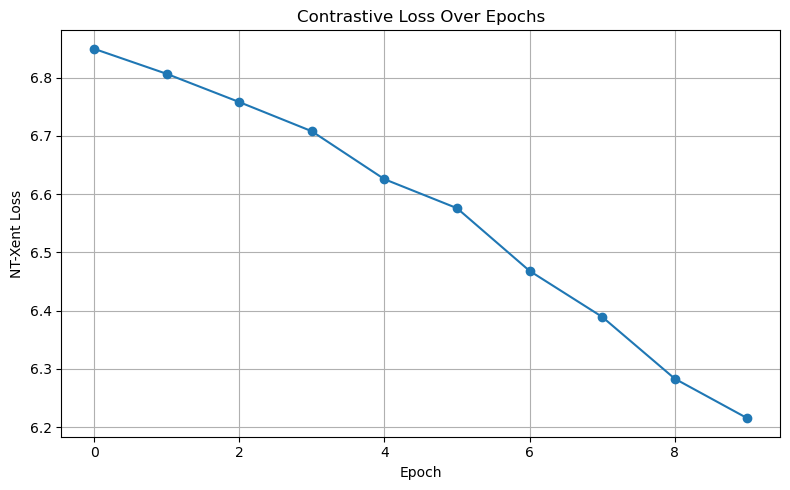

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

encoder = PatchEncoder().to(device)
optimiser = torch.optim.Adam(encoder.parameters(), lr=1e-3)

losses = []

for epoch in range(10):
    pairs = make_augmented_pairs(patches)
    z1 = torch.stack([p[0] for p in pairs]).to(device)
    z2 = torch.stack([p[1] for p in pairs]).to(device)
    h1 = encoder(z1)
    h2 = encoder(z2)
    loss = contrastive_loss(h1, h2)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    
    losses.append(loss.item())
    print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(10), losses, marker='o')
plt.title("Contrastive Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

## Extract Overlapping Patches and Compute Embeddings

A window is slid across the image to extract overlapping patches, which are then embedded using the trained encoder.



In [36]:
def extract_overlapping_patches(image_tensor, patch_size=32, stride=16):
    c, h, w = image_tensor.shape
    patches = []
    positions = []

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = image_tensor[:, y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            positions.append((y, x))

    return torch.stack(patches), positions

original_tensor = TF.ToTensor()(img).to(device) * 2 - 1
overlap_patches, positions = extract_overlapping_patches(original_tensor, patch_size=32, stride=16)
with torch.no_grad():
    embeddings = encoder(overlap_patches.to(device)).cpu().numpy()

## Cluster Embeddings and Build Segmentation Map

The process involves using K-Means clustering on patch embeddings to assign region labels and reconstruct a segmentation map.


In [37]:
num_clusters = 10  
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(embeddings)
labels = kmeans.labels_

c:\Users\Windows PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [38]:
label_map = -1 * np.ones((original_tensor.shape[1], original_tensor.shape[2]), dtype=np.int32)
count_map = np.zeros_like(label_map, dtype=np.int32)
patch_size = 32
stride = 16

for (y, x), label in zip(positions, labels):
    label_map[y:y+patch_size, x:x+patch_size] += label
    count_map[y:y+patch_size, x:x+patch_size] += 1

label_map = label_map / np.maximum(count_map, 1)

## Visualise Segmentation Results

These visualisations illustrate how well the model differentiates between distinct regions within the image based on the learned representations.

Note: Colors are not semantically meaningful, they simply represent cluster IDs.



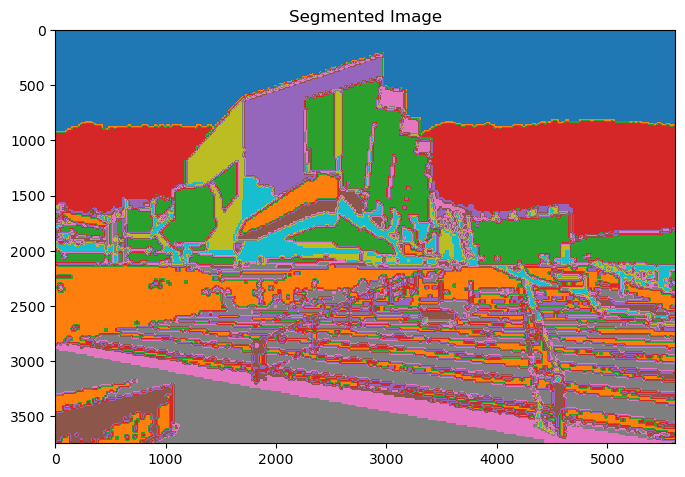

In [39]:
plt.figure(figsize=(8, 6))
plt.imshow(label_map, cmap='tab10')  
plt.axis('on')
plt.title('Segmented Image')
plt.show()

## Varying Number of Clusters

To assess the impact of the number of clusters on segmentation quality, the clustering and reconstruction process was repeated for multiple values of `num_clusters` (3, 5, 7, and 10). This variation enables a visual and qualitative analysis of how segmentation granularity changes, ranging from coarse groupings to finer distinctions. Such an evaluation helps determine an appropriate level of detail for the specific application or dataset under consideration.


c:\Users\Windows PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


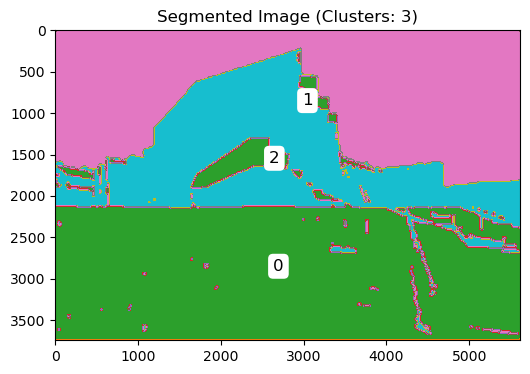

c:\Users\Windows PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


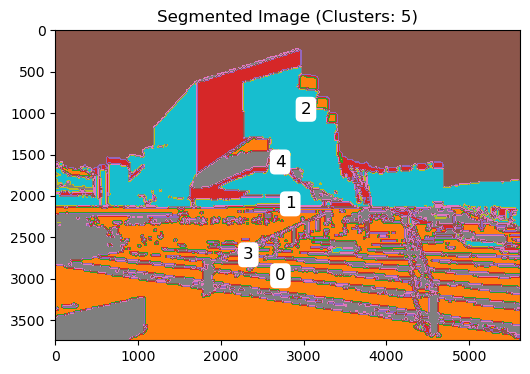

c:\Users\Windows PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


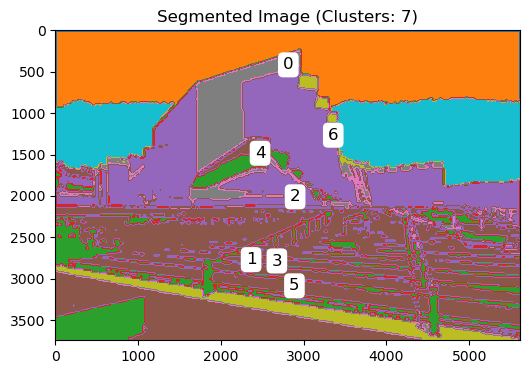

c:\Users\Windows PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


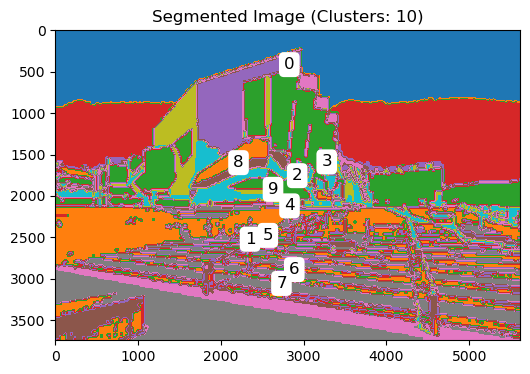

In [40]:
for num_clusters in [3, 5, 7, 10]:
    kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(embeddings)
    labels = kmeans.labels_

    label_map = -1 * np.ones((original_tensor.shape[1], original_tensor.shape[2]), dtype=np.int32)
    count_map = np.zeros_like(label_map, dtype=np.int32)

    for (y, x), label in zip(positions, labels):
        label_map[y:y+patch_size, x:x+patch_size] += label
        count_map[y:y+patch_size, x:x+patch_size] += 1

    label_map = label_map / np.maximum(count_map, 1)

    plt.figure(figsize=(6, 5))
    plt.imshow(label_map, cmap='tab10')
    plt.title(f'Segmented Image (Clusters: {num_clusters})')
    plt.axis('on')

    #adding labels to clusters for better accessibility and readibility

    for i in range(num_clusters):
        mask = (label_map.round() == i)
        if np.any(mask):
            cy, cx = center_of_mass(mask)
            plt.text(cx, cy, str(i), color='black', fontsize=12, ha='center', va='center',
                     bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

    plt.show()